### Importing libraries

In [7]:
import os
import tensorflow as tf
import numpy as np
import pywt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix
from tensorflow.keras.layers import Multiply, concatenate,Conv1D, Conv2D
from tensorflow.keras.losses import binary_crossentropy
import cv2
import random
from skimage.filters import gabor
import matplotlib.pyplot as plt
from PIL import Image 
from skimage import filters
from tensorflow.keras import layers
import albumentations as A
from keras import backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import regularizers
from sklearn.model_selection import KFold
from tensorflow.keras.metrics import Precision
from sklearn.metrics import roc_auc_score
from tensorflow.keras.metrics import AUC
import tensorflow as tf
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import Callback

### Data Preprocessing

In [8]:
images_dir = "/kaggle/input/polyps-dataset/TestDataset/TestDataset/CVC-300/images"
masks_dir = "/kaggle/input/polyps-dataset/TestDataset/TestDataset/CVC-300/masks"

In [9]:
# Count the number of image files in the images directory
image_filenames = [filename for filename in os.listdir(images_dir)]
num_images = len(image_filenames)

# Count the number of mask files in the masks directory
mask_filenames = [filename for filename in os.listdir(masks_dir)]
num_masks = len(mask_filenames)

print(f"Number of images: {num_images}")
print(f"Number of masks: {num_masks}")

Number of images: 60
Number of masks: 60


#### Displaying an image and its corresponding mask

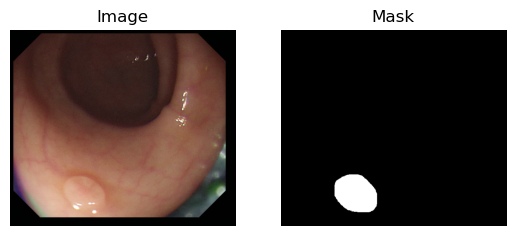

In [10]:
# Choose the index of the image and mask pair you want to display
index = 5

# Load and display the image
image_path = os.path.join(images_dir, image_filenames[index])
image = Image.open(image_path)

plt.subplot(1, 2, 1)
plt.title("Image")
plt.imshow(image)
plt.axis("off")

# Load and display the corresponding mask
mask_path = os.path.join(masks_dir, mask_filenames[index])
mask = Image.open(mask_path)

plt.subplot(1, 2, 2)
plt.title("Mask")
plt.imshow(mask)
plt.axis("off")

plt.show()

### Augmentation techniques using Albumentation transforms

### New augmentations

In [11]:
# Albumentations transformations that should be applied to both image and mask
geom_transforms = [
    A.HorizontalFlip(),
    A.VerticalFlip(),
    A.RandomRotate90(),
]

# Albumentations transformations that should be applied only to the image
image_transforms = [
    A.RandomBrightnessContrast(p=0.3),
    A.RandomGamma(p=0.3),
    A.CLAHE(p=0.3),
]

# Compose the transformations to create the final transform function
geom_transform = A.Compose(geom_transforms)
image_transform = A.Compose(image_transforms)

In [12]:
def augment(image, mask):
    # Convert the tensors to numpy arrays
    image = image.numpy()
    mask = mask.numpy()

    # Apply the geometric transformations
    augmented = geom_transform(image=image, mask=mask)

    # Apply the image-only transformations
    image = image_transform(image=augmented['image'])

    # Convert the augmented images and masks back to tensors
    augmented_image = tf.convert_to_tensor(image)
    augmented_mask = tf.convert_to_tensor(augmented['mask'])
    return augmented_image, augmented_mask

In [13]:
def tf_augment(image, mask):
    augmented_image, augmented_mask = tf.py_function(func=augment, inp=[image, mask], Tout=(tf.float32, tf.uint8))
    return augmented_image, augmented_mask

In [ ]:
def view_augmentation(image, mask, aug_function):
    """
    Function to view an image before and after augmentation

    Args:
        image: The image to augment
        mask: The mask corresponding to the image
        aug_function: The augmentation function to apply
    """
    # Augment the image and mask
    augmented_image, augmented_mask = aug_function(image, mask)

    # Display the original and augmented images
    plt.figure(figsize=(16, 8))

    plt.subplot(1, 4, 1)
    plt.title("Original Image")
    plt.imshow(image)
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.title("Original Mask")
    plt.imshow(mask, cmap='gray')
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.title("Augmented Image")
    plt.imshow(augmented_image)
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.title("Augmented Mask")
    plt.imshow(augmented_mask, cmap='gray')
    plt.axis("off")

    plt.show()

# Choose the index of the image and mask pair you want to display
index = 10

# Load the image and mask
image_path = os.path.join(images_dir, image_filenames[index])
image = Image.open(image_path)
mask_path = os.path.join(masks_dir, mask_filenames[index])
mask = Image.open(mask_path)

# Convert image and mask to tensors
image = tf.convert_to_tensor(np.array(image), dtype=tf.float32) / 255.0
mask = tf.convert_to_tensor(np.array(mask), dtype=tf.uint8)

# View the image before and after augmentation
view_augmentation(image, mask, tf_augment)

### Wavelet transformation 

In [14]:
def wavelet_transform(image):
    # Ensure image is a numpy array
    image = image.numpy()
    coeffs = pywt.dwt2(image, 'bior1.3')
    LL, (LH, HL, HH) = coeffs
    LL = tf.image.resize(LL, [256, 256])
    LH = tf.image.resize(LH, [256, 256])
    HL = tf.image.resize(HL, [256, 256])
    HH = tf.image.resize(HH, [256, 256])
    return tf.concat([LL, LH, HL, HH], axis=-1)

def load_image(image_path):
    # Load the image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [256, 256])  # Update the image size to 256x256
    image = tf.cast(image, tf.float32) / 255.0  # Normalize the image
    
    # Convert the image to grayscale
    gray_image = tf.image.rgb_to_grayscale(image)

    # Perform the wavelet transform
    wavelet_image = tf.py_function(wavelet_transform, [gray_image], tf.float32)

    # Explicitly set the shapes of the tensors
    wavelet_image.set_shape([256, 256, 4])  # Adjust this based on the actual number of channels output by wavelet_transform

    wavelet_image = (wavelet_image - tf.reduce_min(wavelet_image)) / (tf.reduce_max(wavelet_image) - tf.reduce_min(wavelet_image))

    # Select the first channel from Wavelet transformed images
    wavelet_image = wavelet_image[:, :, :1] 

    # Reshape the concatenated image to (256, 256, 4)
    transformed_image = tf.concat([image, wavelet_image], axis=-1)
    print(f"Transformed Training Image shape: {transformed_image.shape}")
    return transformed_image

def load_mask(mask_path):
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256])  
    mask = tf.where(mask > 0, 1, 0)
    return mask

#### Splitting dataset in a 70:15:15 ratio of Training:Validation:Testing data

In [16]:
# Split the selected data into training and the remaining data (validation + testing)
train_images, val_test_images, train_masks, val_test_masks = train_test_split(image_filenames, mask_filenames, test_size=0.3, random_state=42)

# Split the remaining data into validation and testing
val_images, test_images, val_masks, test_masks = train_test_split(val_test_images, val_test_masks, test_size=0.5, random_state=42)

In [17]:
# Display the number of training image samples
print("Number of training image samples:", len(train_images))

# Display the number of validation image samples
print("Number of validation image samples:", len(val_images))

# Display the number of test image samples
print("Number of test image samples:", len(test_images))

Number of training image samples: 42
Number of validation image samples: 9
Number of test image samples: 9


### Input data pipeline

In [18]:
# Create the dataset for training
train_image_dataset = tf.data.Dataset.from_tensor_slices([os.path.join(images_dir, fname) for fname in train_images])
train_mask_dataset = tf.data.Dataset.from_tensor_slices([os.path.join(masks_dir, fname) for fname in train_masks])

# Transform the training images and masks
train_image_dataset = train_image_dataset.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
train_mask_dataset = train_mask_dataset.map(load_mask, num_parallel_calls=tf.data.experimental.AUTOTUNE)

# Apply augmentation to the training dataset
train_dataset = tf.data.Dataset.zip((train_image_dataset, train_mask_dataset))
train_dataset = train_dataset.map(tf_augment, num_parallel_calls=tf.data.experimental.AUTOTUNE)

# Create the dataset for testing
test_image_dataset = tf.data.Dataset.from_tensor_slices([os.path.join(images_dir, fname) for fname in test_images])
test_image_dataset = test_image_dataset.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
test_mask_dataset = tf.data.Dataset.from_tensor_slices([os.path.join(masks_dir, fname) for fname in test_masks])
test_mask_dataset = test_mask_dataset.map(load_mask, num_parallel_calls=tf.data.experimental.AUTOTUNE)

# Create the dataset for validation
val_image_dataset = tf.data.Dataset.from_tensor_slices([os.path.join(images_dir, fname) for fname in val_images])
val_image_dataset = val_image_dataset.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
val_mask_dataset = tf.data.Dataset.from_tensor_slices([os.path.join(masks_dir, fname) for fname in val_masks])
val_mask_dataset = val_mask_dataset.map(load_mask, num_parallel_calls=tf.data.experimental.AUTOTUNE)

# Zip the training image and mask datasets together
train_dataset = tf.data.Dataset.zip((train_image_dataset, train_mask_dataset))

# Zip the validation image and mask datasets together
val_dataset = tf.data.Dataset.zip((val_image_dataset, val_mask_dataset))
val_dataset = val_dataset.batch(16)

# Zip the testing image and mask datasets together
test_dataset = tf.data.Dataset.zip((test_image_dataset, test_mask_dataset))

# Shuffle the training dataset and set the buffer size
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(16)

# Set the batch size for the testing dataset
test_dataset = test_dataset.batch(16)

Transformed Training Image shape: (256, 256, 4)
Transformed Training Image shape: (256, 256, 4)
Transformed Training Image shape: (256, 256, 4)


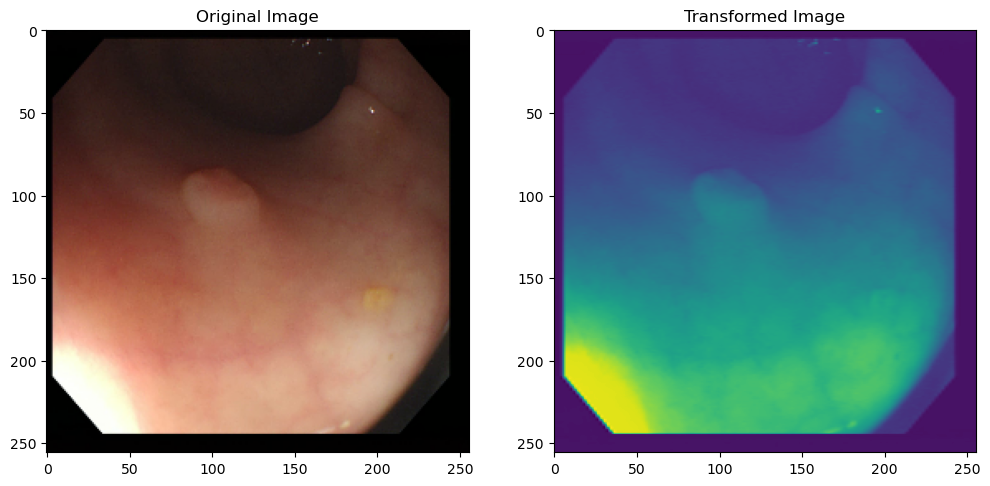

In [19]:
def display_transformations(image_path):
    # Load the image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [256, 256])  # Update the image size to 256x256
    image = tf.cast(image, tf.float32) / 255.0  # Normalize the image

    # Display the original image
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Original Image')

    # Convert the image to grayscale
    gray_image = tf.image.rgb_to_grayscale(image)

    # Perform the wavelet transform
    wavelet_image = tf.py_function(wavelet_transform, [gray_image], tf.float32)

    # Explicitly set the shapes of the tensors
    wavelet_image.set_shape([256, 256, 12])  # Adjust this based on the actual number of channels output by wavelet_transform

    wavelet_image = (wavelet_image - tf.reduce_min(wavelet_image)) / (tf.reduce_max(wavelet_image) - tf.reduce_min(wavelet_image))

    # Select the first channel from Wavelet transformed images
    wavelet_image = wavelet_image[:, :, :1] 

    # Display the transformed image
    plt.subplot(1, 2, 2)
    plt.imshow(tf.squeeze(wavelet_image[:,:,0:3]))
    plt.title('Transformed Image')
    plt.show()

# Display transformations for the first image in your dataset
display_transformations(os.path.join(images_dir, train_images[14]))

#### Computing class frequencies in masks

In [20]:
total_samples = len(train_images) * 256 * 256
polyp_frequencies = 0

# Here, instead of creating a Dataset, we just iterate over mask paths
for mask_path in [os.path.join(masks_dir, fname) for fname in train_masks]:
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [256, 256])  
    mask = tf.where(mask > 0, 1, 0)
    frequency = tf.reduce_sum(tf.cast(mask == 1, tf.int32))
    polyp_frequencies += frequency.numpy()  # Ensure frequency is a python integer, not a tensor

# Compute the frequencies for the background class
background_frequencies = total_samples - polyp_frequencies

# Now compute class weights
polyp_weight = total_samples / (2 * polyp_frequencies) if polyp_frequencies > 0 else 0
background_weight = total_samples / (2 * background_frequencies) if background_frequencies > 0 else 0
class_weights = {0: background_weight, 1: polyp_weight}

### Performance metrics

1. IoU
2. DICE coefficient
3. Hausdorff Distance
4. Balanced Accuracy

In [43]:
def dice_coef(y_true, y_pred, smooth=1):
  intersection = K.sum(y_true * y_pred, axis=[1,2,3])
  union = K.sum(y_true, axis=[1,2,3]) + K.sum(y_pred, axis=[1,2,3])
  dice = K.mean((2. * intersection + smooth)/(union + smooth), axis=0)
  return dice

def iou_coef(y_true, y_pred, smooth=1):
  intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
  union = K.sum(y_true,[1,2,3])+K.sum(y_pred,[1,2,3])-intersection
  iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
  return iou

In [37]:
def hausdorff_distance(y_true, y_pred):
  """Computes the Hausdorff Distance metric."""
  y_true = tf.cast(y_true, tf.float32)
  y_pred = tf.cast(y_pred, tf.float32)
  
  # flatten y_true and y_pred
  a = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
  b = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

  a_norm = tf.reduce_sum(tf.square(a), axis=1)
  b_norm = tf.reduce_sum(tf.square(b), axis=1)

  a_norm = tf.sqrt(a_norm)
  b_norm = tf.sqrt(b_norm)

  hd = tf.maximum(
      tf.reduce_max(tf.reduce_sum(tf.abs(a - b), axis=1) / a_norm),
      tf.reduce_max(tf.reduce_sum(tf.abs(b - a), axis=1) / b_norm))
  
  return hd

In [21]:
def balanced_accuracy(y_true, y_pred):
    y_pred = K.round(y_pred)  # Round to 0 or 1
    
    tp = K.sum(K.cast(y_true*y_pred, 'float'), axis=[1,2,3])
    tn = K.sum(K.cast((1-y_true)*(1-y_pred), 'float'), axis=[1,2,3])
    fp = K.sum(K.cast((1-y_true)*y_pred, 'float'), axis=[1,2,3])
    fn = K.sum(K.cast(y_true*(1-y_pred), 'float'), axis=[1,2,3])

    p = tp / (tp + fn + K.epsilon())
    n = tn / (tn + fp + K.epsilon())

    balanced_acc = (p+n)/2
    
    return balanced_acc


In [25]:
def f1_score(y_true, y_pred, smooth=1):
    tp = K.sum(y_true * y_pred, axis=[1, 2, 3])
    fp = K.sum(y_pred, axis=[1, 2, 3]) - tp
    fn = K.sum(y_true, axis=[1, 2, 3]) - tp
    precision = tp / (tp + fp + smooth)
    recall = tp / (tp + fn + smooth)
    f1 = 2. * (precision * recall) / (precision + recall + smooth)
    return K.mean(f1, axis=0)

### DiceBCELoss

In [26]:
def weighted_binary_crossentropy(target, output, from_logits=False):
    # Calculate the binary cross entropy
    bce = tf.keras.backend.binary_crossentropy(target, output, from_logits=from_logits)

    # Apply the weights
    weight_vector = target * class_weights[1] + (1. - target) * class_weights[0]
    weighted_bce = weight_vector * bce

    return tf.keras.backend.mean(weighted_bce)

In [27]:
def DiceBCELoss(targets, inputs, smooth=1e-6):
    # Flatten label and prediction tensors
    inputs = tf.keras.backend.flatten(inputs)
    targets = tf.keras.backend.flatten(tf.cast(targets, 'float32'))

    BCE = weighted_binary_crossentropy(targets, inputs)
    intersection = tf.keras.backend.sum(targets * inputs)
    dice_loss = 1 - (2 * intersection + smooth) / (tf.keras.backend.sum(targets) + tf.keras.backend.sum(inputs) + smooth)
    Dice_BCE = BCE + dice_loss

    return Dice_BCE

precision = Precision(name='precision')

#### Visualizing test dataset

In [ ]:
def visualize_dataset(dataset, num_samples=3):
    plt.figure(figsize=(12, 6))
    samples = dataset.take(num_samples)

    for i, (image, mask) in enumerate(samples):
        # Squeeze the batch dimension and take the first 3 channels (RGB)
        image = image[0, :, :, :3].numpy()
        mask = mask[0, :, :, 0].numpy()  # Squeeze the batch and channel dimensions

        # Display the image
        plt.subplot(num_samples, 2, 2*i+1)
        plt.imshow(image)
        plt.title('Image')

        # Display the mask
        plt.subplot(num_samples, 2, 2*i+2)
        plt.imshow(mask, cmap='gray')
        plt.title('Mask')

    plt.tight_layout()
    plt.show()
    
# Visualize some samples from the training dataset
visualize_dataset(test_dataset)

## U-Net model architecture

In [28]:
def spatial_kernel_size(input, beta=1, gamma=2):
    """
    The original implementation based the kernel size on the channel, but with
    square images, it can be simplified to:
    k = | log2(R)/gamma + b/gamma|odd
    """

    k = int(abs(np.log2((input.shape[1])/gamma) + beta/gamma))
    out = k if k % 2 else k + 1

    return out

def channel_kernel_size(input, beta=1,gamma=2):
    """
    k = | log2(C)/gamma + b/gamma|odd
    """
    k = int(abs(np.log2(input.shape[-1]/gamma) + beta/gamma))
    out = k if k % 2 else k + 1
    return out

def spatial_attention_block(input, stats):
    """ Adaptive spatial attention block
    """

    k_size = spatial_kernel_size(input)

    # generate spatial statistics
    if (stats == 'mean') or (stats == 'mean_max'):
        mean = tf.reduce_mean(input, axis=-1, keepdims=True)
        t = mean

    if (stats == 'max') or (stats == 'mean_max'):
        maximum = tf.reduce_max(input, axis=-1, keepdims=True)
        t = maximum

    if (stats == 'mean_max'):
        t = concatenate([mean,maximum], axis=-1)

    t = Conv2D(1, kernel_size=k_size, padding="same",activation='sigmoid', use_bias = False)(t)

    return t

def channel_attention_block(input, stats):
    """ Adaptive channel attention block
    """

    k_size = channel_kernel_size(input)

    # generate channel statistics
    if (stats == 'mean') or (stats == 'mean_max'):
        mean = tf.reduce_mean(input, axis=[1,2], keepdims=True)
        mean = tf.squeeze(mean,axis=(-2))
        mean = tf.transpose(mean,perm=[0,2,1])
        t = mean

    if (stats == 'max') or (stats == 'mean_max'):
        maximum = tf.reduce_max(input, axis=[1,2], keepdims=True)
        maximum = tf.squeeze(maximum,axis=(-2))
        maximum = tf.transpose(maximum,perm=[0,2,1])
        t = maximum

    if (stats == 'mean_max'):
        t = concatenate([mean,maximum], axis=-1)

    t = Conv1D(filters=1, kernel_size=k_size, padding='same', use_bias=False)(t)
    t = tf.transpose(t,perm=[0,2,1])
    t = tf.expand_dims(t,(-2))
    t = tf.math.sigmoid(t)

    return t

In [29]:
def attention_block(gating_signal, inter_signal, n_filters):
    """ 
    Here we replace the simple gating attention with the adaptive spatial and channel attention.
    """

    # Apply channel attention
    channel_attention = channel_attention_block(gating_signal, 'mean_max')
    gating_signal = Multiply()([gating_signal, channel_attention])

    # Apply spatial attention
    spatial_attention = spatial_attention_block(gating_signal, 'mean_max')
    gating_signal = Multiply()([gating_signal, spatial_attention])

    # Continue with your attention gating as before
    gating_signal = layers.Conv2D(n_filters, (1, 1), padding='same')(gating_signal)
    inter_signal = layers.Conv2D(n_filters, (1, 1), padding='same')(inter_signal)

    concat_feat = layers.Add()([gating_signal, inter_signal])
    concat_feat = layers.Activation('relu')(concat_feat)

    attention_weights = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid')(concat_feat)

    return layers.Multiply()([inter_signal, attention_weights])

In [30]:
def unet_model_definition():
    inputs = tf.keras.Input(shape=(256, 256, 4))  # Input shape matches the shape of the filtered image
    
    # Encoder
    conv1 = layers.Conv2D(64, 3, padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    conv1 = layers.Conv2D(64, 3, padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Activation('relu')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)
    pool1 = layers.Dropout(0.1)(pool1)
    
    conv2 = layers.Conv2D(128, 3, padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    conv2 = layers.Conv2D(128, 3, padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Activation('relu')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)
    pool2 = layers.Dropout(0.2)(pool2)
    
    conv3 = layers.Conv2D(256, 3, padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Activation('relu')(conv3)
    conv3 = layers.Conv2D(256, 3, padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Activation('relu')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)
    pool3 = layers.Dropout(0.3)(pool3)
    
    conv4 = layers.Conv2D(512, 3, padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Activation('relu')(conv4)
    conv4 = layers.Conv2D(512, 3, padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Activation('relu')(conv4)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)
    pool4 = layers.Dropout(0.4)(pool4)
    
    # Bridge
    conv5 = layers.Conv2D(1024, 3, padding='same')(pool4)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Activation('relu')(conv5)
    conv5 = layers.Conv2D(1024, 3, padding='same')(conv5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Activation('relu')(conv5)
    conv5 = layers.Dropout(0.5)(conv5)

    # Decoder
    up1 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    merge1 = layers.concatenate([conv4, up1], axis=3)
    attention1 = attention_block(up1, conv4, 512)
    conv6 = layers.Conv2D(512, 3, padding='same')(attention1)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.Activation('relu')(conv6)
    conv6 = layers.Conv2D(512, 3, padding='same')(conv6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.Activation('relu')(conv6)
    conv6 = layers.Dropout(0.4)(conv6)

    up2 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    merge2 = layers.concatenate([conv3, up2], axis=3)
    attention2 = attention_block(up2, conv3, 256)
    conv7 = layers.Conv2D(256, 3, padding='same')(attention2)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.Activation('relu')(conv7)
    conv7 = layers.Conv2D(256, 3, padding='same')(conv7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.Activation('relu')(conv7)
    conv7 = layers.Dropout(0.3)(conv7)

    up3 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    merge3 = layers.concatenate([conv2, up3], axis=3)
    attention3 = attention_block(up3,conv2, 128)
    conv8 = layers.Conv2D(128, 3, padding='same')(attention3)
    conv8 = layers.BatchNormalization()(conv8)
    conv8 = layers.Activation('relu')(conv8)
    conv8 = layers.Conv2D(128, 3, padding='same')(conv8)
    conv8 = layers.BatchNormalization()(conv8)
    conv8 = layers.Activation('relu')(conv8)
    conv8 = layers.Dropout(0.2)(conv8)
    
    up4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    merge4 = layers.concatenate([conv1, up4], axis=3)
    attention4 = attention_block(up4,conv1, 64)
    conv9 = layers.Conv2D(64, 3, padding='same')(attention4)
    conv9 = layers.BatchNormalization()(conv9)
    conv9 = layers.Activation('relu')(conv9)
    conv9 = layers.Conv2D(64, 3, padding='same')(conv9)
    conv9 = layers.BatchNormalization()(conv9)
    conv9 = layers.Activation('relu')(conv9)
    conv9 = layers.Dropout(0.1)(conv9)
    
    # Output
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv9)
    
    # Create the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    return model

model = unet_model_definition()

In [ ]:
# model.save("u-netmodel.h5")

In [ ]:
from tensorflow.keras.utils import plot_model

# Assume 'model' is your built model
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [31]:
model.load_weights('/kaggle/input/weightssss/cvc300-weightssss.h5')

## Hold-out cross validation

In [32]:
class CyclicLR(Callback):
    def __init__(self, base_lr=0.001, max_lr=0.01, step_size=2000, mode='triangular'):
        super(CyclicLR, self).__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size
        self.mode = mode
        self.cycle = 0
        self.iterations = 0

    def on_train_begin(self, logs=None):
        if self.mode == 'triangular':
            self.mode = 1
        elif self.mode == 'triangular2':
            self.mode = 2
        else:
            raise ValueError('Invalid mode. Supported modes: "triangular", "triangular2".')

    def on_batch_begin(self, batch, logs=None):
        self.iterations += 1
        x = self.iterations / self.step_size
        cycle = int(1 + x // 2)
        x_in_cycle = abs(x - 2 * cycle + 1)
        relative_pos = 1 - x_in_cycle if x_in_cycle <= 1 else x_in_cycle - 1

        if self.mode == 1:
            lr = self.base_lr + (self.max_lr - self.base_lr) * max(0, 1 - relative_pos)
        else:
            lr = self.base_lr + (self.max_lr - self.base_lr) * max(0, (1 - relative_pos) / (2 ** (cycle - 1)))

        tf.keras.backend.set_value(self.model.optimizer.lr, lr)

        self.cycle = cycle

# Example usage with SGD optimizer
base_lr = 0.001
max_lr = 0.01
step_size = 2000
mode = 'triangular'

optimizer = SGD(learning_rate=base_lr)

In [40]:
model.compile(optimizer=optimizer, loss=DiceBCELoss, metrics=['accuracy', dice_coef, iou_coef, balanced_accuracy, hausdorff_distance])

clr_callback = CyclicLR(base_lr=base_lr, max_lr=max_lr, step_size=step_size, mode=mode)

history = model.fit(train_dataset, validation_data=val_dataset, epochs=10, callbacks=[clr_callback])

Epoch 1/10


2023-06-21 18:24:20.592204: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


3/3 [==============================] - 11s 2s/step - loss: 0.0751 - accuracy: 0.9965 - dice_coef: 0.9457 - iou_coef: 0.8978 - balanced_accuracy: 0.9897 - hausdorff_distance: 7.9336 - val_loss: 0.4742 - val_accuracy: 0.9801 - val_dice_coef: 0.7137 - val_iou_coef: 0.6083 - val_balanced_accuracy: 0.9824 - val_hausdorff_distance: 241.8661
Epoch 2/10
3/3 [==============================] - 5s 1s/step - loss: 0.0696 - accuracy: 0.9967 - dice_coef: 0.9468 - iou_coef: 0.8996 - balanced_accuracy: 0.9929 - hausdorff_distance: 7.7044 - val_loss: 0.4681 - val_accuracy: 0.9806 - val_dice_coef: 0.7133 - val_iou_coef: 0.6085 - val_balanced_accuracy: 0.9818 - val_hausdorff_distance: 229.7259
Epoch 3/10
3/3 [==============================] - 5s 1s/step - loss: 0.0671 - accuracy: 0.9967 - dice_coef: 0.9464 - iou_coef: 0.8988 - balanced_accuracy: 0.9935 - hausdorff_distance: 6.8741 - val_loss: 0.4765 - val_accuracy: 0.9802 - val_dice_coef: 0.7272 - val_iou_coef: 0.6276 - val_balanced_accuracy: 0.9812 - va

In [ ]:
# model.save_weights('/kaggle/working/colon_weights_v2.h5')

### Evaluating on test dataset

In [41]:
score = model.evaluate(test_dataset, verbose=1)

1/1 [==============================] - 0s 463ms/step - loss: 0.1444 - accuracy: 0.9958 - dice_coef: 0.9029 - iou_coef: 0.8246 - balanced_accuracy: 0.9836 - hausdorff_distance: 14.7142


In [ ]:
val_predictions = model.predict(val_dataset)

# Reshape the masks and the predictions to 1D array for ROC calculation
val_masks = np.concatenate([y.numpy() for x, y in val_dataset], axis=0).reshape(-1)
val_predictions = val_predictions.reshape(-1)

# Compute the ROC curve and the AUC
fpr, tpr, _ = roc_curve(val_masks, val_predictions)
roc_auc = auc(fpr, tpr)

In [ ]:
# plot ROC curve
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

### Plotting Loss, Accuracy, IoU and DICE score curves

In [ ]:
# Plotting the metrics
plt.figure(figsize=(12, 6))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Evolution')
plt.legend()

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Adjust subplot spacing
plt.tight_layout()

# Show the plots
plt.show()

In [ ]:
# Plotting the metrics
plt.figure(figsize=(12, 6))

# IoU Coefficient
plt.subplot(1, 2, 1)
plt.plot(history.history['iou_coef'], label='Train IoU Coefficient')
plt.plot(history.history['val_iou_coef'], label='Validation IoU Coefficient')
plt.title('IoU Coefficient Evolution')
plt.legend()

# Dice Coefficient
plt.subplot(1, 2, 2)
plt.plot(history.history['dice_coef'], label='Train Dice Coefficient')
plt.plot(history.history['val_dice_coef'], label='Validation Dice Coefficient')
plt.title('Dice Coefficient Evolution')
plt.legend()

# Adjust subplot spacing
plt.tight_layout()

# Show the plots
plt.show()

In [ ]:
def display_images(images, true_masks, predicted_masks):
    fig, axes = plt.subplots(len(images), 3, figsize=(15, 5*len(images)))
    
    # Flatten the axes for easier iteration
    axes = axes.ravel()
    
    for i, (image, true_mask, predicted_mask) in enumerate(zip(images, true_masks, predicted_masks)):
        # Display the input image (first channel)
        axes[i*3].imshow(image[..., 0])
        axes[i*3].set_title('Input Image')
        axes[i*3].axis('off')

        # Display the true mask
        axes[i*3 + 1].imshow(true_mask)
        axes[i*3 + 1].set_title('True Mask')
        axes[i*3 + 1].axis('off')

        # Display the predicted mask
        axes[i*3 + 2].imshow(predicted_mask)
        axes[i*3 + 2].set_title('Predicted Mask')
        axes[i*3 + 2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [ ]:
# Select random samples from the test dataset
sample_batches = list(test_dataset.take(5))

# Prepare empty lists for images, masks, and predictions
sample_images, sample_masks, predicted_masks = [], [], []

for image, mask in sample_batches:
    # Make predictions on the sample image
    predicted_mask = model.predict(image)
    
    # Threshold the predicted mask
    predicted_mask = (predicted_mask > 0.5).astype(int)

    # Append the image, mask, and predicted mask to their respective lists
    sample_images.append(image[0])
    sample_masks.append(mask[0])
    predicted_masks.append(predicted_mask[0])

# Display the images
display_images(sample_images, sample_masks, predicted_masks)

In [ ]:
model.summary()

## 5-fold Cross validation

In [ ]:
# Define the number of splits for KFold
n_splits = 5

# Convert the datasets to numpy arrays to use with KFold
X = np.array(list(train_image_dataset.as_numpy_iterator()))
y = np.array(list(train_mask_dataset.as_numpy_iterator()))

# Create a KFold object
kfold = KFold(n_splits=n_splits, shuffle=True)

# Initialize lists to store the performance metrics for each fold
accuracy_list = []
precision_list = []
dice_list = []
iou_list = []
f1_score_list = []
auc_list = []
loss_list = []

# Initialize a list to store the history objects for each fold
history_list = []

# Loop over each fold
fold_no = 1
for train, test in kfold.split(X, y):
    print(f'Training for fold {fold_no}...')
    # Create a new Precision object for this fold
    precision = Precision(name='precision')

    # Create a new model for each fold
    model = unet_model_definition()
    optimizer = SGD(learning_rate=base_lr)
    model.compile(optimizer=optimizer, loss=DiceBCELoss, metrics=['accuracy', dice_coef, iou_coef, f1_score, precision])

    clr_callback = CyclicLR(base_lr=base_lr, max_lr=max_lr, step_size=step_size, mode=mode)

    # Train the model and obtain the history object
    history = model.fit(X[train], y[train], batch_size=16, epochs=1, validation_data=(X[test], y[test]), callbacks=[clr_callback])

    # Save the model after each fold
    model.save(f'model_{fold_no}.h5')
    
    # Save the history object to the list
    history_list.append(history)

    # Add the performance metrics to the lists
    accuracy_list.append(history.history['accuracy'][-1])
    precision_list.append(history.history['precision'][-1])
    dice_list.append(history.history['dice_coef'][-1])
    iou_list.append(history.history['iou_coef'][-1])
    loss_list.append(history.history['loss'][-1])

    # Get the predictions on the validation set
    y_pred = model.predict(X[test])
    
    # Binarize the predictions using a threshold
    y_pred_binary = (y_pred > 0.5).astype(np.uint8)
    
    # Flatten the arrays
    y_test_flatten = y[test].flatten()
    y_pred_binary_flatten = y_pred_binary.flatten()

    y_test_reshaped = y_test_flatten.reshape(-1, 256, 256, 1).astype(np.float32)
    y_pred_binary_reshaped = y_pred_binary_flatten.reshape(-1, 256, 256, 1).astype(np.float32)
    
    # Calculate the F1 score and append to the list
    f1 = f1_score(y_test_reshaped, y_pred_binary_reshaped)
    f1_score_list.append(f1)
    
    # Print metrics for each fold
    print(f"Fold {fold_no} metrics:")
    print(f"Accuracy: {history.history['accuracy'][-1]}")
    print(f"Precision: {history.history['precision'][-1]}")
    print(f"Dice Coefficient: {history.history['dice_coef'][-1]}")
    print(f"IoU: {history.history['iou_coef'][-1]}")
    print(f"F1 Score: {f1}")
    print(f"Loss: {history.history['loss'][-1]}\n")

    fold_no += 1

In [ ]:
import sklearn

# ...

# Load the sample weights
sample_weights_path = '/kaggle/input/weightssss/cvc300-weightssss.h5'
sample_model = unet_model_definition()
sample_model.load_weights(sample_weights_path)

# Convert the datasets to numpy arrays to use with KFold
X = np.array(list(train_image_dataset.as_numpy_iterator()))
y = np.array(list(train_mask_dataset.as_numpy_iterator()))

# Create a KFold object
kfold = KFold(n_splits=n_splits, shuffle=True)

# Initialize lists to store the performance metrics for each fold
accuracy_list = []
precision_list = []
dice_list = []
iou_list = []
f1_score_list = []
auc_list = []
loss_list = []

# Initialize a list to store the history objects for each fold
history_list = []

# Loop over each fold
fold_no = 1
for train, test in kfold.split(X, y):
    print(f'Training for fold {fold_no}...')
    # Create a new Precision object for this fold
    precision = Precision(name='precision')

    # Create a new model for each fold and load the sample weights
    model = unet_model_definition()
    model.set_weights(sample_model.get_weights())  # Set the weights from the sample model

    optimizer = SGD(learning_rate=base_lr)
    model.compile(optimizer=optimizer, loss=DiceBCELoss, metrics=['accuracy', dice_coef, iou_coef, f1_score, precision])

    clr_callback = CyclicLR(base_lr=base_lr, max_lr=max_lr, step_size=step_size, mode=mode)

    # Define the checkpoint path for each fold
    checkpoint_path = f'model_{fold_no}.h5'

    # Define the ModelCheckpoint callback to save the best weights
    checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        checkpoint_path, save_weights_only=True, save_best_only=True, monitor='val_loss', mode='min'
    )

    # Train the model and obtain the history object
    history = model.fit(
        X[train], y[train], batch_size=16, epochs=1, validation_data=(X[test], y[test]),
        callbacks=[clr_callback, checkpoint_callback]  # Include the checkpoint callback
    )

    # Load the best weights for the fold
    model.load_weights(checkpoint_path)

    # Save the model after each fold
    model.save(f'model_{fold_no}.h5')

    # Save the history object to the list
    history_list.append(history)

    # Add the performance metrics to the lists
    accuracy_list.append(history.history['accuracy'][-1])
    precision_list.append(history.history['precision'][-1])
    dice_list.append(history.history['dice_coef'][-1])
    iou_list.append(history.history['iou_coef'][-1])
    loss_list.append(history.history['loss'][-1])

    # Get the predictions on the validation set
    y_pred = model.predict(X[test])

    # Binarize the predictions using a threshold
    y_pred_binary = (y_pred > 0.5).astype(np.uint8)

    # Flatten the arrays
    y_test_flatten = y[test].flatten()
    y_pred_binary_flatten = y_pred_binary.flatten()
    
    # Flatten the arrays
    y_test_flatten = y[test].flatten()
    y_pred_binary_flatten = y_pred_binary.flatten()

    y_test_reshaped = y_test_flatten.reshape(-1, 256, 256, 1).astype(np.float32)
    y_pred_binary_reshaped = y_pred_binary_flatten.reshape(-1, 256, 256, 1).astype(np.float32)
    
    # Calculate the F1 score and append to the list
    f1 = f1_score(y_test_reshaped, y_pred_binary_reshaped)
    f1_score_list.append(f1)

    # Print metrics for each fold
    print(f"Fold {fold_no} metrics:")
    print(f"Accuracy: {history.history['accuracy'][-1]}")
    print(f"Precision: {history.history['precision'][-1]}")
    print(f"Dice Coefficient: {history.history['dice_coef'][-1]}")
    print(f"IoU: {history.history['iou_coef'][-1]}")
    print(f"F1 Score: {f1}")
    print(f"Loss: {history.history['loss'][-1]}\n")

    fold_no += 1

In [ ]:
y[test].shape

In [ ]:
y_test_reshaped.shape

In [ ]:
y_pred_binary.shape

In [ ]:
y_pred_binary_reshaped.shape

In [ ]:
# calculate the mean and standard deviation of the metrics
mean_accuracy = np.mean(accuracy_list)
std_accuracy = np.std(accuracy_list)

# Calculate mean and standard deviation for precision
mean_precision = np.mean(precision_list)
std_precision = np.std(precision_list)

# Calculate mean and standard deviation for dice coefficient
mean_dice = np.mean(dice_list)
std_dice = np.std(dice_list)

# Calculate mean and standard deviation for IoU
mean_iou = np.mean(iou_list)
std_iou = np.std(iou_list)

# Calculate mean and standard deviation for F1 score
mean_f1_score = np.mean(f1_score_list)
std_f1_score = np.std(f1_score_list)

# Calculate mean and standard deviation for AUC
mean_auc = np.mean(auc_list)
std_auc = np.std(auc_list)

# Calculate mean and standard deviation for loss
mean_loss = np.mean(loss_list)
std_loss = np.std(loss_list)

# Display mean and standard deviation of accuracy
print(f"Accuracy: Mean = {mean_accuracy:.4f}, Std = {std_accuracy:.4f}")

# Display mean and standard deviation of precision
print(f"Precision: Mean = {mean_precision:.4f}, Std = {std_precision:.4f}")

# Display mean and standard deviation of dice coefficient
print(f"Dice Coefficient: Mean = {mean_dice:.4f}, Std = {std_dice:.4f}")

# Display mean and standard deviation of IoU
print(f"IoU: Mean = {mean_iou:.4f}, Std = {std_iou:.4f}")

# Display mean and standard deviation of F1 score
print(f"F1 Score: Mean = {mean_f1_score:.4f}, Std = {std_f1_score:.4f}")

# Display mean and standard deviation of AUC
print(f"AUC: Mean = {mean_auc:.4f}, Std = {std_auc:.4f}")

# Display mean and standard deviation of loss
print(f"Loss: Mean = {mean_loss:.4f}, Std = {std_loss:.4f}")

In [ ]:
# Initialize the list to store mean values
mean_train_acc, mean_val_acc = [], []
mean_train_loss, mean_val_loss = [], []

# Calculate mean values
for history in history_list:
    mean_train_acc.append(history.history['accuracy'])
    mean_val_acc.append(history.history['val_accuracy'])
    mean_train_loss.append(history.history['loss'])
    mean_val_loss.append(history.history['val_loss'])

mean_train_acc = np.mean(mean_train_acc, axis=0)
mean_val_acc = np.mean(mean_val_acc, axis=0)
mean_train_loss = np.mean(mean_train_loss, axis=0)
mean_val_loss = np.mean(mean_val_loss, axis=0)

# Plotting accuracy
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(mean_train_acc)
plt.plot(mean_val_acc)
plt.title('Mean Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plotting loss
plt.subplot(1, 2, 2)
plt.plot(mean_train_loss)
plt.plot(mean_val_loss)
plt.title('Mean Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc as roc_auc_score

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
fprs = []
tprs_interp = []

for fold_no in range(n_splits):
    y_true = y[test].ravel()  
    y_pred = model.predict(X[test]).ravel()

    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    roc_auc = roc_auc_score(fpr, tpr)
    aucs.append(roc_auc)

    # Interpolate tpr at each fpr
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Store the fpr and tpr for each fold
    fprs.append(fpr)
    tprs_interp.append(tpr)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = roc_auc_score(mean_fpr, mean_tpr)

plt.figure()
plt.plot(mean_fpr, mean_tpr, color='purple', linestyle='-', linewidth=2, label='Mean ROC (AUC = %0.2f)' % mean_auc)
for i in range(n_splits):
    plt.plot(fprs[i], tprs_interp[i], color='gray', linestyle='--', linewidth=1, label='Fold %d ROC' % (i+1))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import sys
import tensorflow as tf
import keras

print("Python version:", sys.version)
print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)